In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sales-dataset/sales_data.csv


In [2]:
df = pd.read_csv("/kaggle/input/sales-dataset/sales_data.csv")

In [3]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [5]:
col_num = []
col_obj = []

for col in df.columns:
    if df[col].dtype == 'object':
        col_obj.append(col)
    else :
        col_num.append(col)

In [6]:
col_num

['Product_ID',
 'Sales_Amount',
 'Quantity_Sold',
 'Unit_Cost',
 'Unit_Price',
 'Discount']

In [7]:
col_obj

['Sale_Date',
 'Sales_Rep',
 'Region',
 'Product_Category',
 'Customer_Type',
 'Payment_Method',
 'Sales_Channel',
 'Region_and_Sales_Rep']

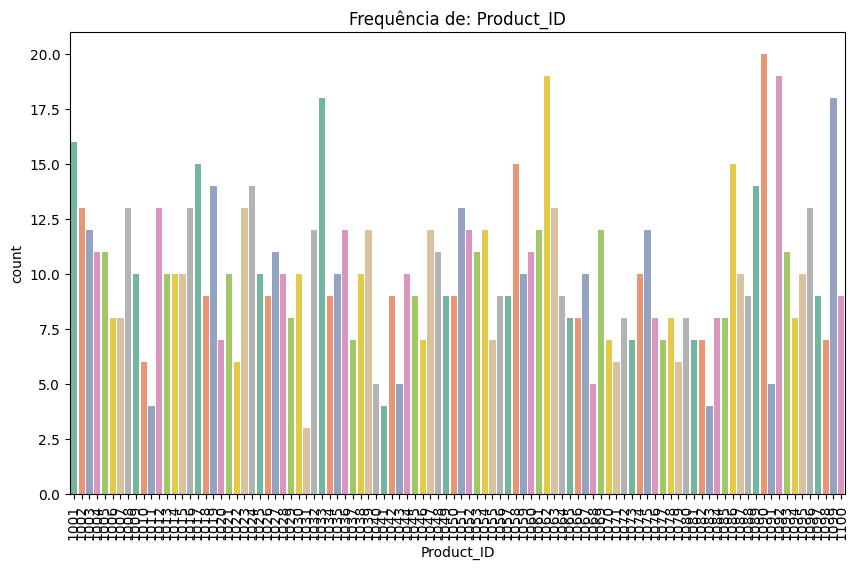

Frequência da coluna Product_ID:
    Product_ID  Frequência
0         1090          20
1         1062          19
2         1092          19
3         1099          18
4         1033          18
..         ...         ...
95        1040           5
96        1011           4
97        1041           4
98        1083           4
99        1031           3

[100 rows x 2 columns]


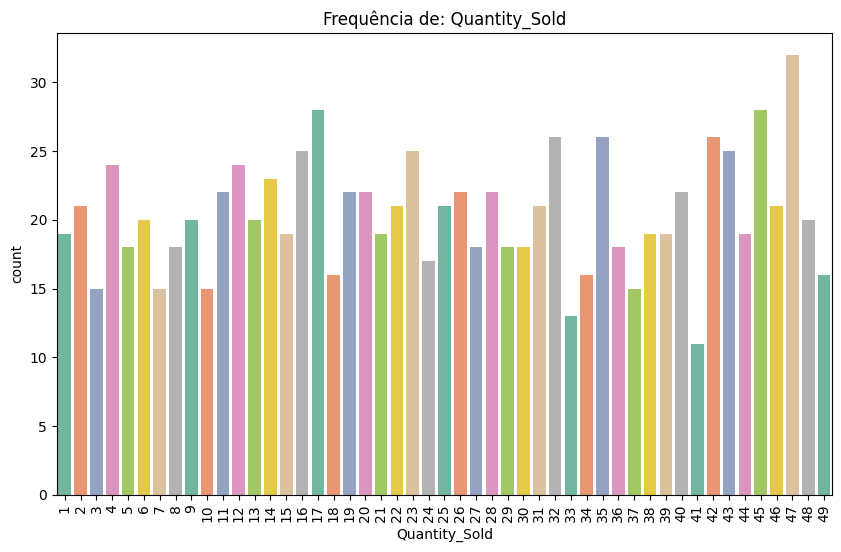

Frequência da coluna Quantity_Sold:
    Quantity_Sold  Frequência
0              47          32
1              45          28
2              17          28
3              42          26
4              32          26
5              35          26
6              23          25
7              43          25
8              16          25
9              12          24
10              4          24
11             14          23
12             26          22
13             11          22
14             20          22
15             28          22
16             19          22
17             40          22
18              2          21
19             25          21
20             22          21
21             46          21
22             31          21
23             13          20
24              9          20
25             48          20
26              6          20
27             39          19
28             38          19
29             44          19
30             21          19
31  

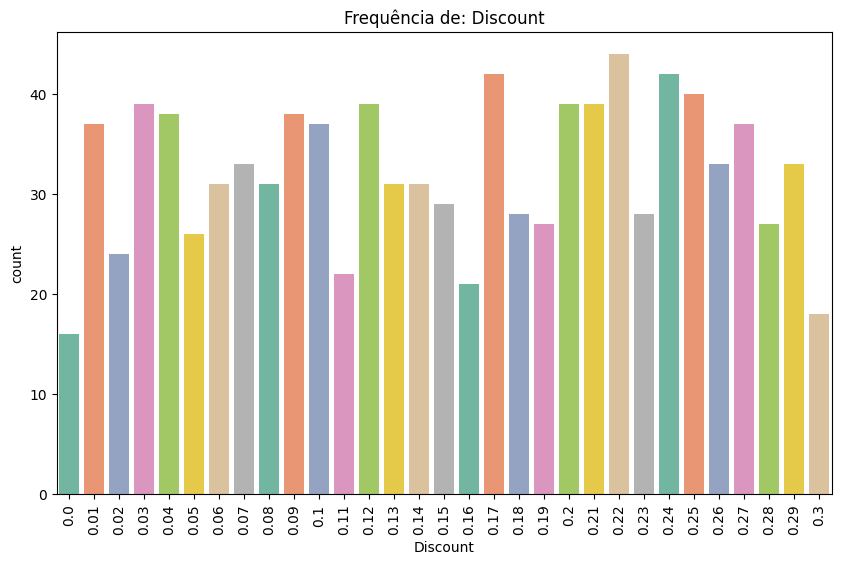

Frequência da coluna Discount:
    Discount  Frequência
0       0.22          44
1       0.17          42
2       0.24          42
3       0.25          40
4       0.20          39
5       0.21          39
6       0.12          39
7       0.03          39
8       0.09          38
9       0.04          38
10      0.27          37
11      0.10          37
12      0.01          37
13      0.26          33
14      0.07          33
15      0.29          33
16      0.06          31
17      0.13          31
18      0.14          31
19      0.08          31
20      0.15          29
21      0.23          28
22      0.18          28
23      0.28          27
24      0.19          27
25      0.05          26
26      0.02          24
27      0.11          22
28      0.16          21
29      0.30          18
30      0.00          16


In [8]:
col_pular = ['Sales_Amount', 'Unit_Cost', 'Unit_Price']
for col in col_num:
    if col in col_pular:
        continue
    plt.figure(figsize=(10, 6))
    plt.title(f"Frequência de: {col}")
    plt.xlabel(f"{col}")
    plt.ylabel("Frequência")
    sns.countplot(data=df, x=col, palette="Set2")
    plt.xticks(rotation=90)
    plt.show()  # Exibe o gráfico
    # Conta a frequência dos valores na coluna
    qtd = df[col].value_counts().reset_index(name='Frequência')
    qtd.columns = [col, 'Frequência']
    # Imprime as frequências
    print(f'Frequência da coluna {col}:')
    print(qtd)

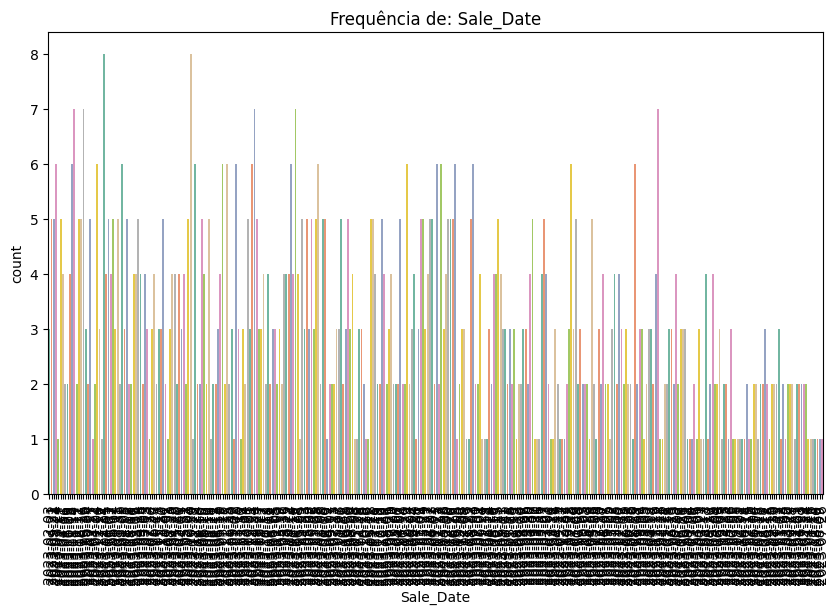

Frequência da coluna Sale_Date:
      Sale_Date  Frequência
0    2023-11-14           8
1    2023-10-20           8
2    2023-10-15           7
3    2023-11-24           7
4    2023-01-12           7
..          ...         ...
335  2023-05-24           1
336  2023-11-27           1
337  2023-01-19           1
338  2023-01-18           1
339  2023-07-26           1

[340 rows x 2 columns]


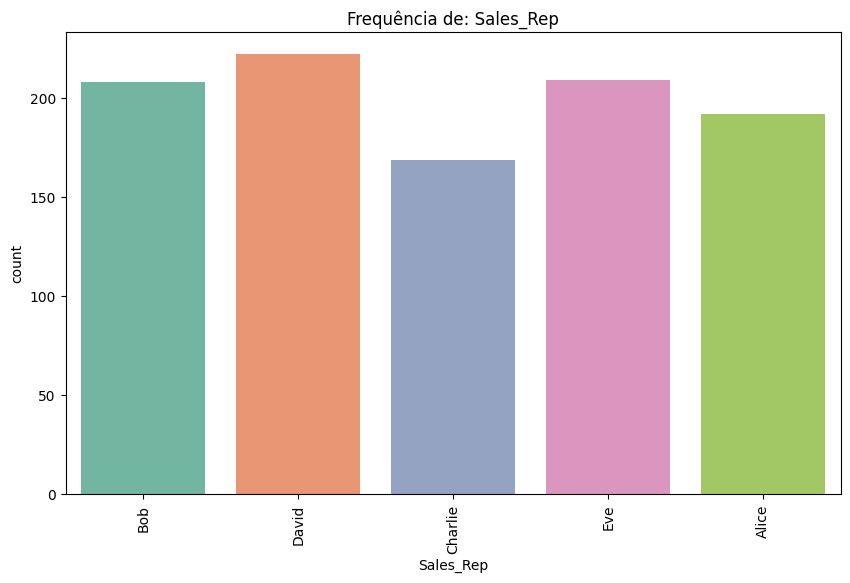

Frequência da coluna Sales_Rep:
  Sales_Rep  Frequência
0     David         222
1       Eve         209
2       Bob         208
3     Alice         192
4   Charlie         169


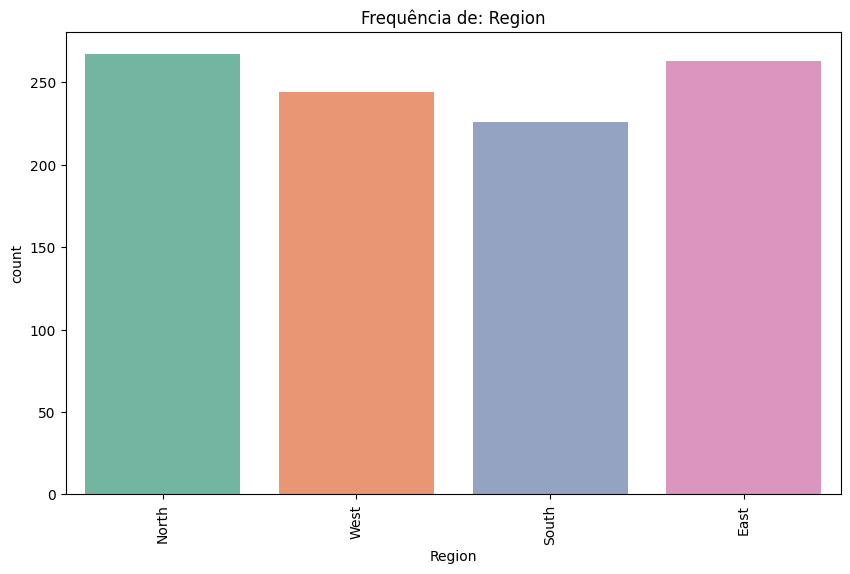

Frequência da coluna Region:
  Region  Frequência
0  North         267
1   East         263
2   West         244
3  South         226


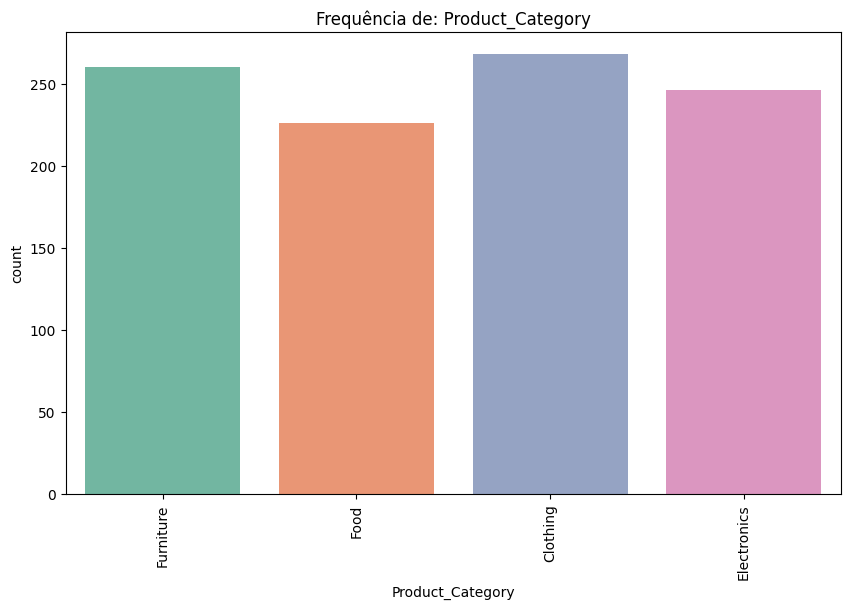

Frequência da coluna Product_Category:
  Product_Category  Frequência
0         Clothing         268
1        Furniture         260
2      Electronics         246
3             Food         226


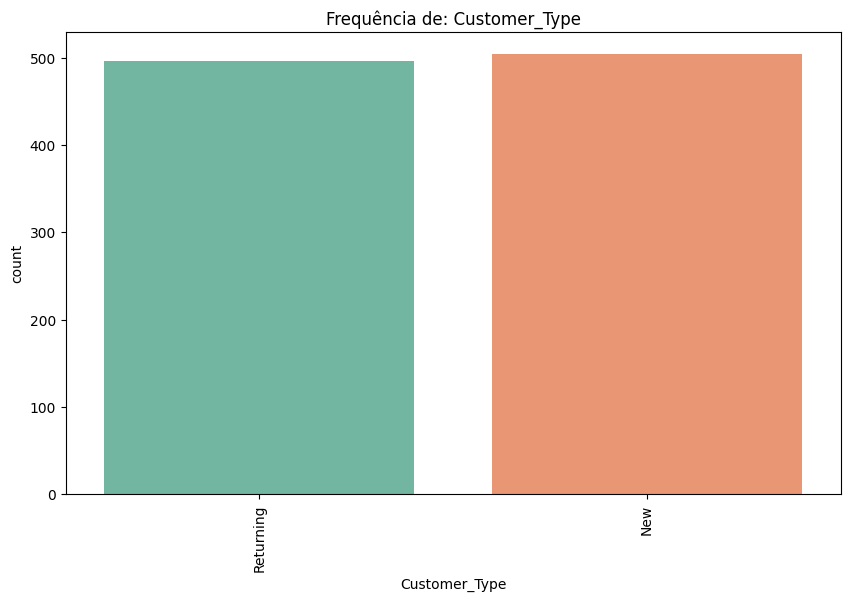

Frequência da coluna Customer_Type:
  Customer_Type  Frequência
0           New         504
1     Returning         496


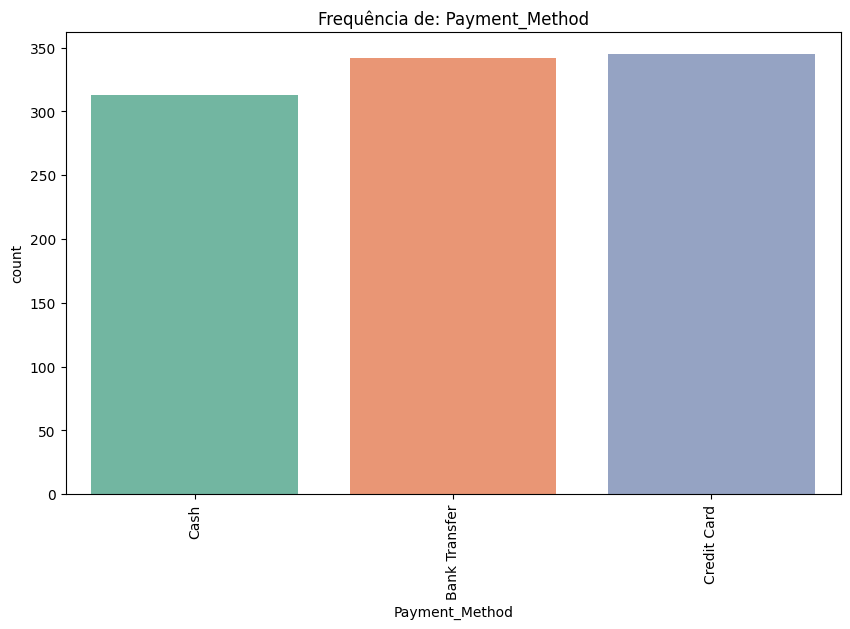

Frequência da coluna Payment_Method:
  Payment_Method  Frequência
0    Credit Card         345
1  Bank Transfer         342
2           Cash         313


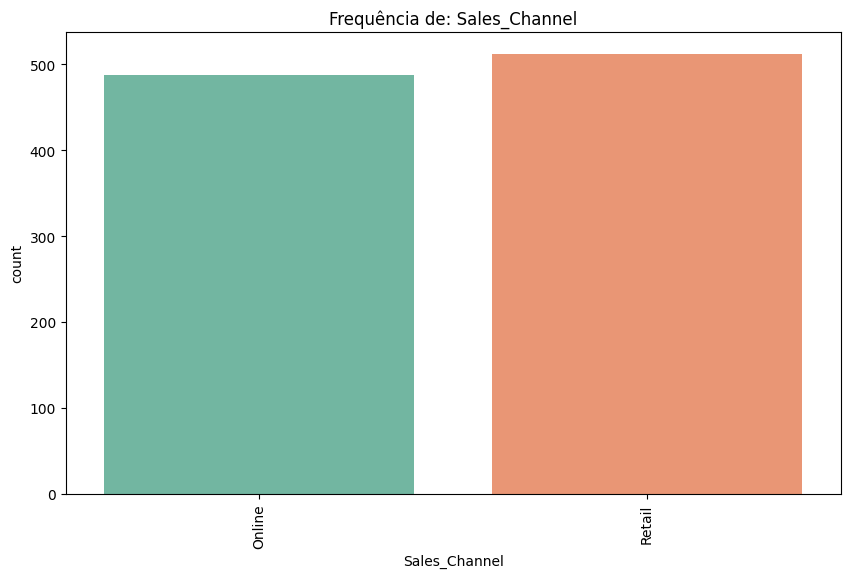

Frequência da coluna Sales_Channel:
  Sales_Channel  Frequência
0        Retail         512
1        Online         488


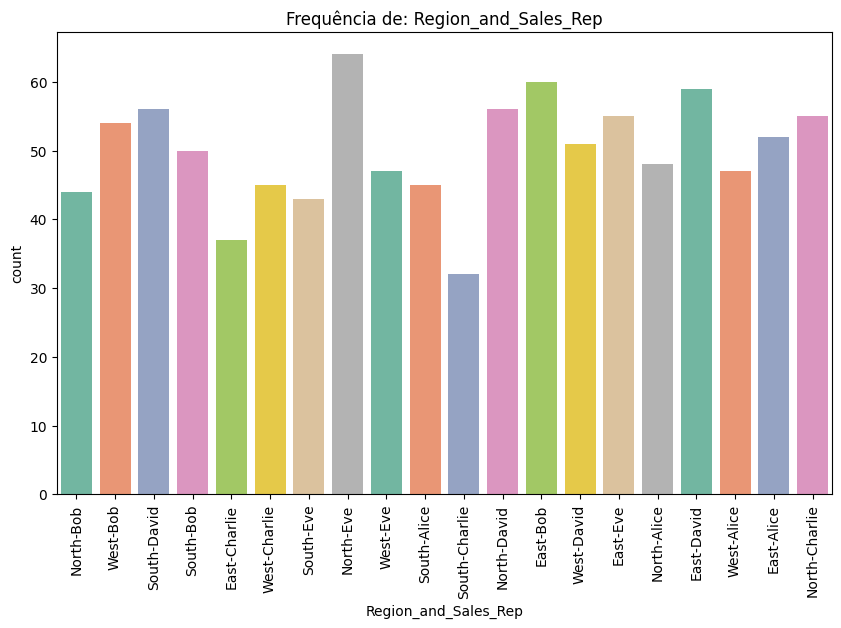

Frequência da coluna Region_and_Sales_Rep:
   Region_and_Sales_Rep  Frequência
0             North-Eve          64
1              East-Bob          60
2            East-David          59
3           South-David          56
4           North-David          56
5         North-Charlie          55
6              East-Eve          55
7              West-Bob          54
8            East-Alice          52
9            West-David          51
10            South-Bob          50
11          North-Alice          48
12           West-Alice          47
13             West-Eve          47
14         West-Charlie          45
15          South-Alice          45
16            North-Bob          44
17            South-Eve          43
18         East-Charlie          37
19        South-Charlie          32


In [9]:
for col in col_obj:
    plt.figure(figsize=(10, 6))
    plt.title(f"Frequência de: {col}")
    plt.xlabel(f"{col}")
    plt.ylabel("Frequência")
    sns.countplot(data=df, x=col, palette="Set2")
    plt.xticks(rotation=90)
    plt.show()  # Exibe o gráfico
    # Conta a frequência dos valores na coluna
    qtd = df[col].value_counts().reset_index(name='Frequência')
    qtd.columns = [col, 'Frequência']
    # Imprime as frequências
    print(f'Frequência da coluna {col}:')
    print(qtd)

# Forma de pagamento mais frequente

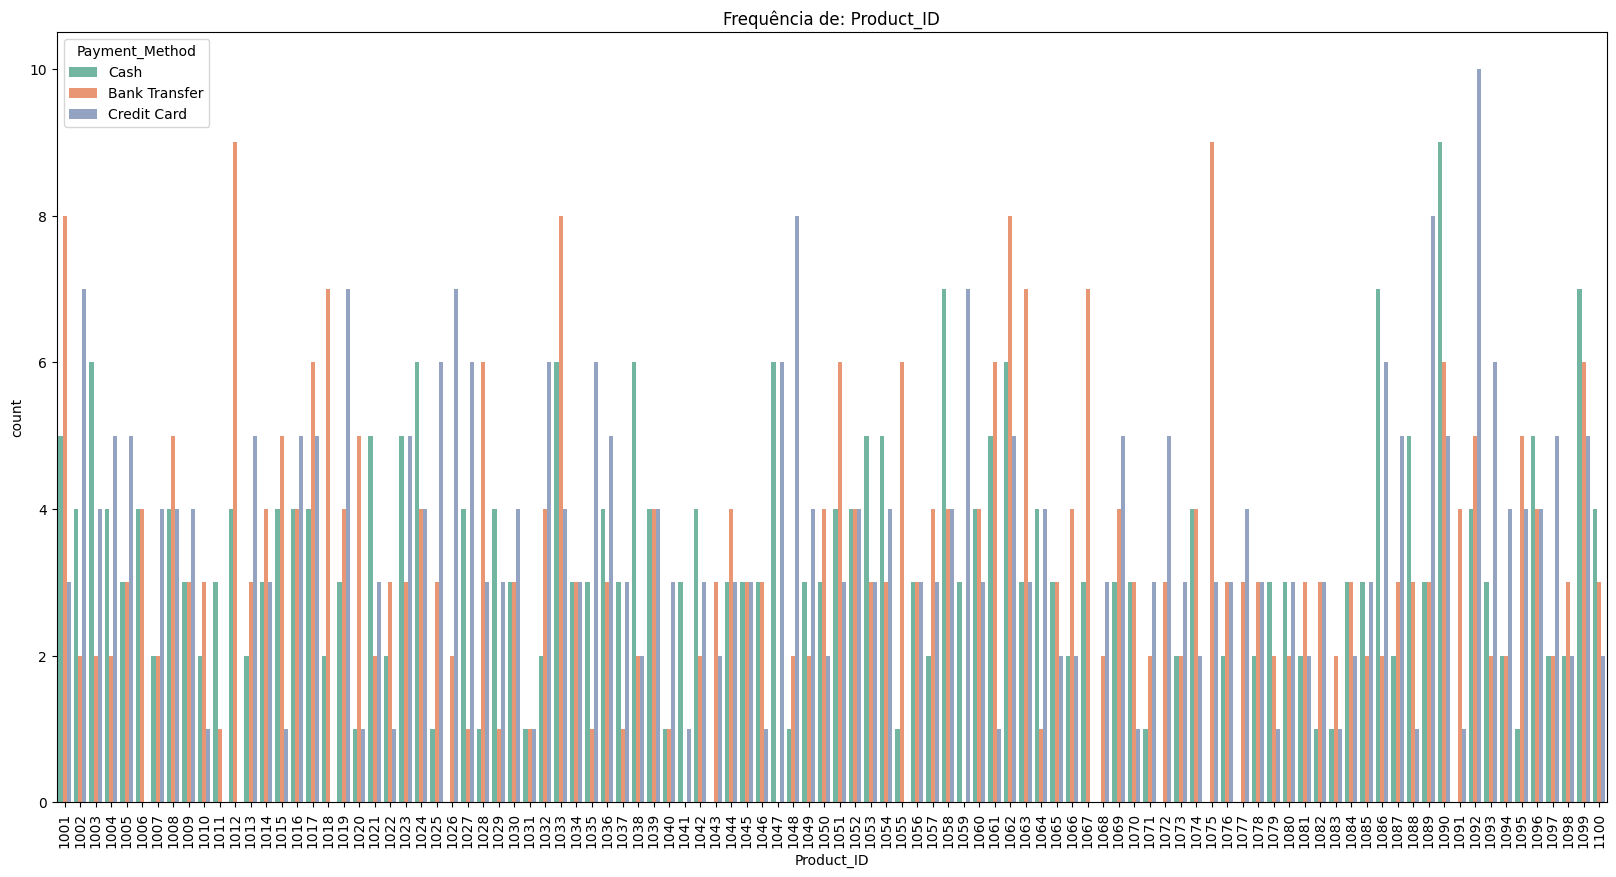

Frequência da coluna Product_ID:
     Product_ID Payment_Method  Frequência
0          1001  Bank Transfer           8
1          1001           Cash           5
2          1001    Credit Card           3
3          1002  Bank Transfer           2
4          1002           Cash           4
..          ...            ...         ...
279        1099           Cash           7
280        1099    Credit Card           5
281        1100  Bank Transfer           3
282        1100           Cash           4
283        1100    Credit Card           2

[284 rows x 3 columns]


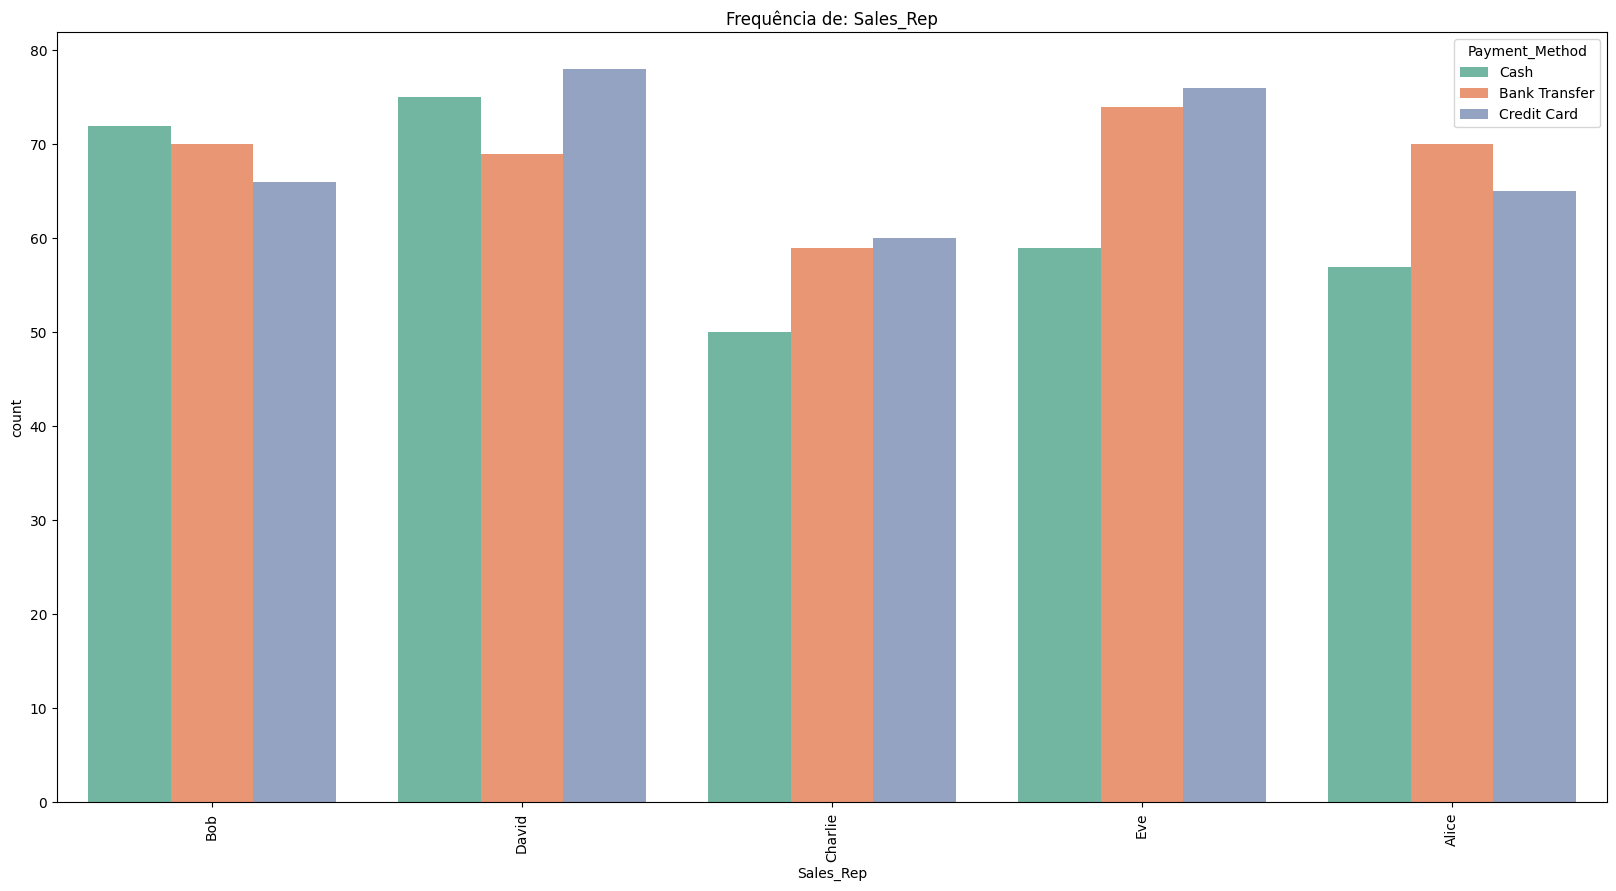

Frequência da coluna Sales_Rep:
   Sales_Rep Payment_Method  Frequência
0      Alice  Bank Transfer          70
1      Alice           Cash          57
2      Alice    Credit Card          65
3        Bob  Bank Transfer          70
4        Bob           Cash          72
5        Bob    Credit Card          66
6    Charlie  Bank Transfer          59
7    Charlie           Cash          50
8    Charlie    Credit Card          60
9      David  Bank Transfer          69
10     David           Cash          75
11     David    Credit Card          78
12       Eve  Bank Transfer          74
13       Eve           Cash          59
14       Eve    Credit Card          76


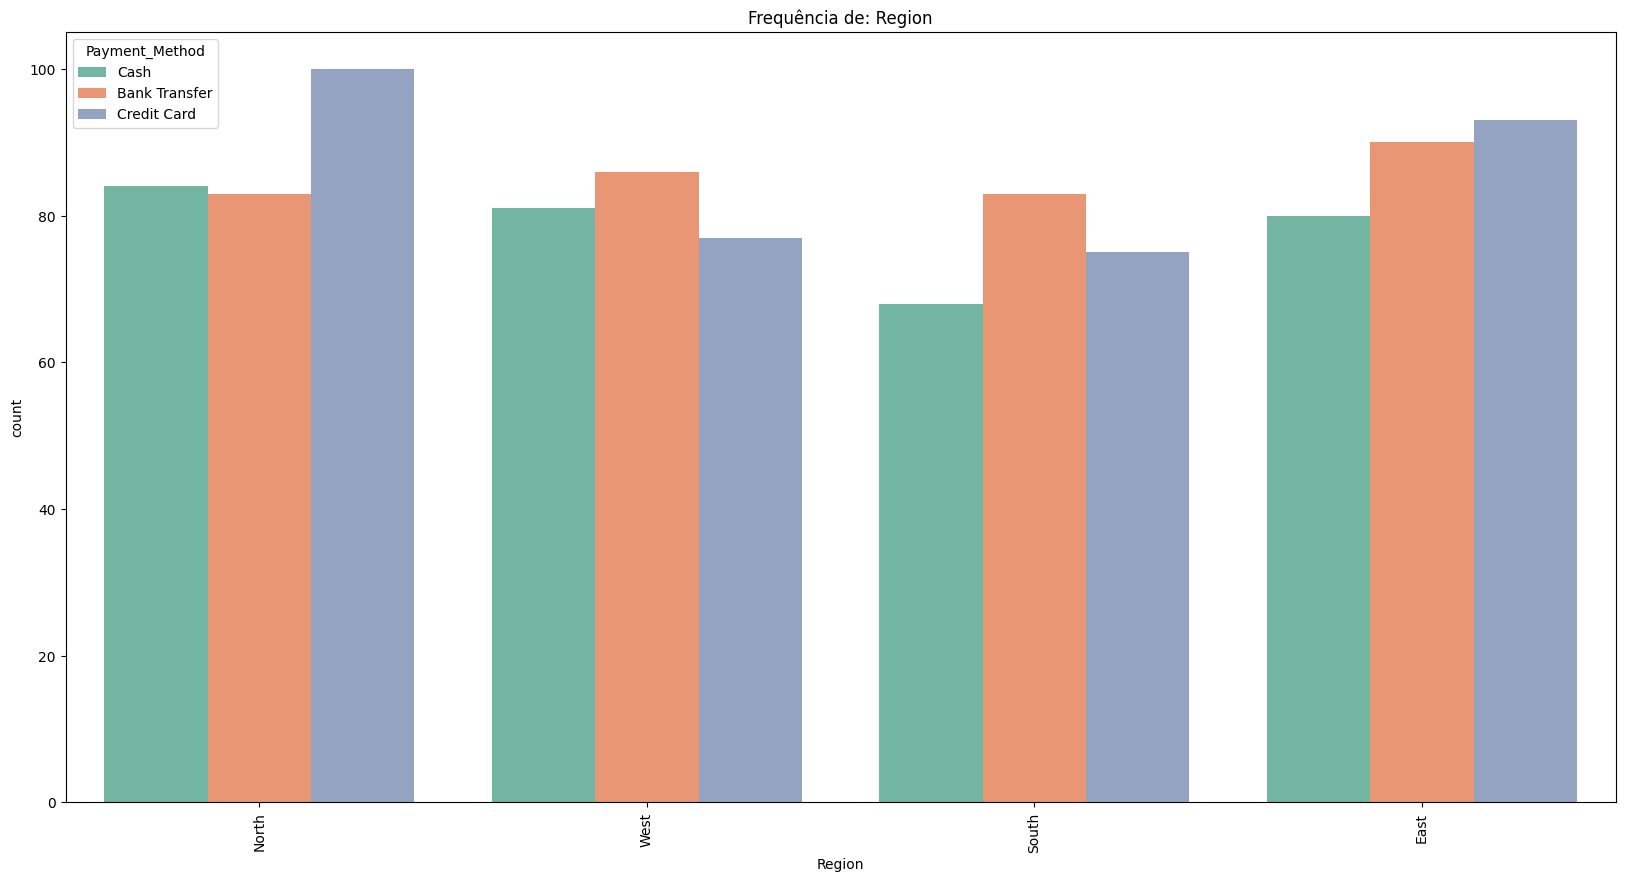

Frequência da coluna Region:
   Region Payment_Method  Frequência
0    East  Bank Transfer          90
1    East           Cash          80
2    East    Credit Card          93
3   North  Bank Transfer          83
4   North           Cash          84
5   North    Credit Card         100
6   South  Bank Transfer          83
7   South           Cash          68
8   South    Credit Card          75
9    West  Bank Transfer          86
10   West           Cash          81
11   West    Credit Card          77


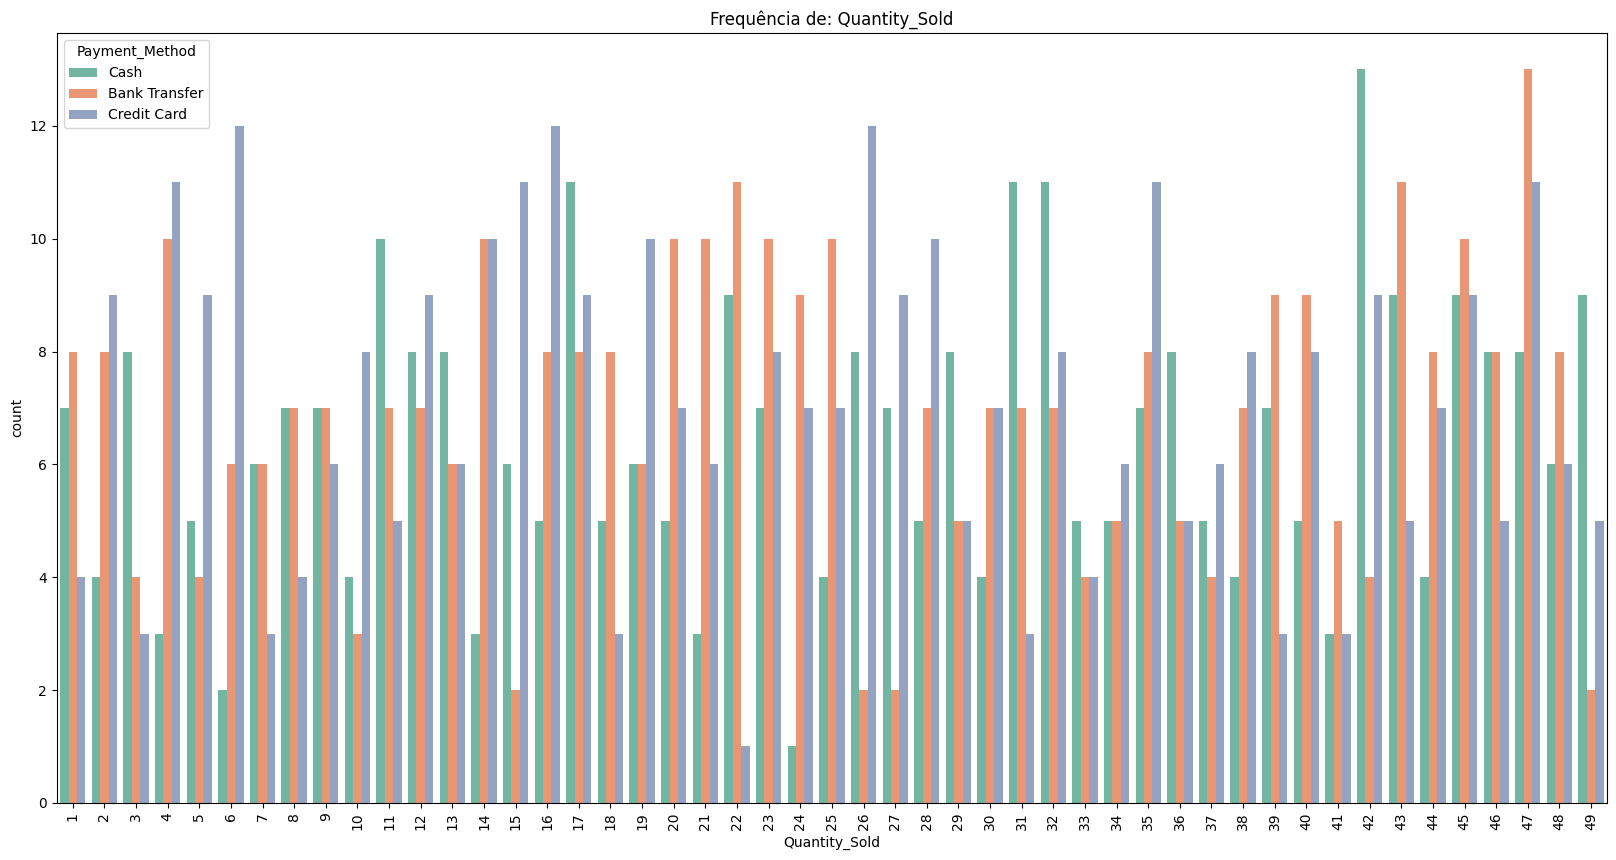

Frequência da coluna Quantity_Sold:
     Quantity_Sold Payment_Method  Frequência
0                1  Bank Transfer           8
1                1           Cash           7
2                1    Credit Card           4
3                2  Bank Transfer           8
4                2           Cash           4
..             ...            ...         ...
142             48           Cash           6
143             48    Credit Card           6
144             49  Bank Transfer           2
145             49           Cash           9
146             49    Credit Card           5

[147 rows x 3 columns]


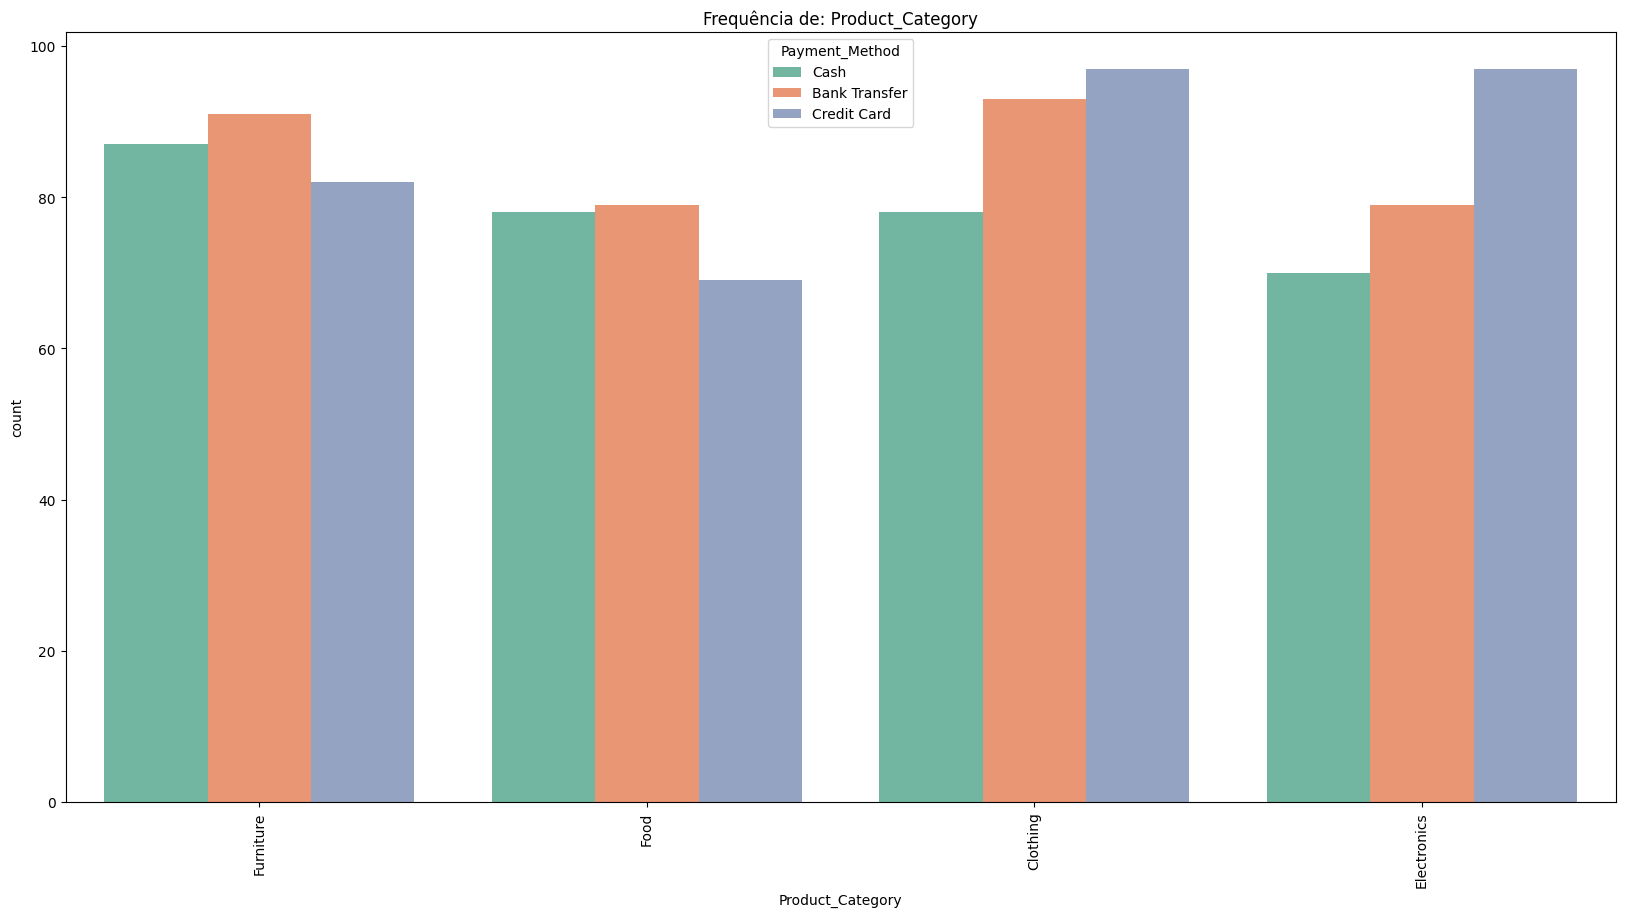

Frequência da coluna Product_Category:
   Product_Category Payment_Method  Frequência
0          Clothing  Bank Transfer          93
1          Clothing           Cash          78
2          Clothing    Credit Card          97
3       Electronics  Bank Transfer          79
4       Electronics           Cash          70
5       Electronics    Credit Card          97
6              Food  Bank Transfer          79
7              Food           Cash          78
8              Food    Credit Card          69
9         Furniture  Bank Transfer          91
10        Furniture           Cash          87
11        Furniture    Credit Card          82


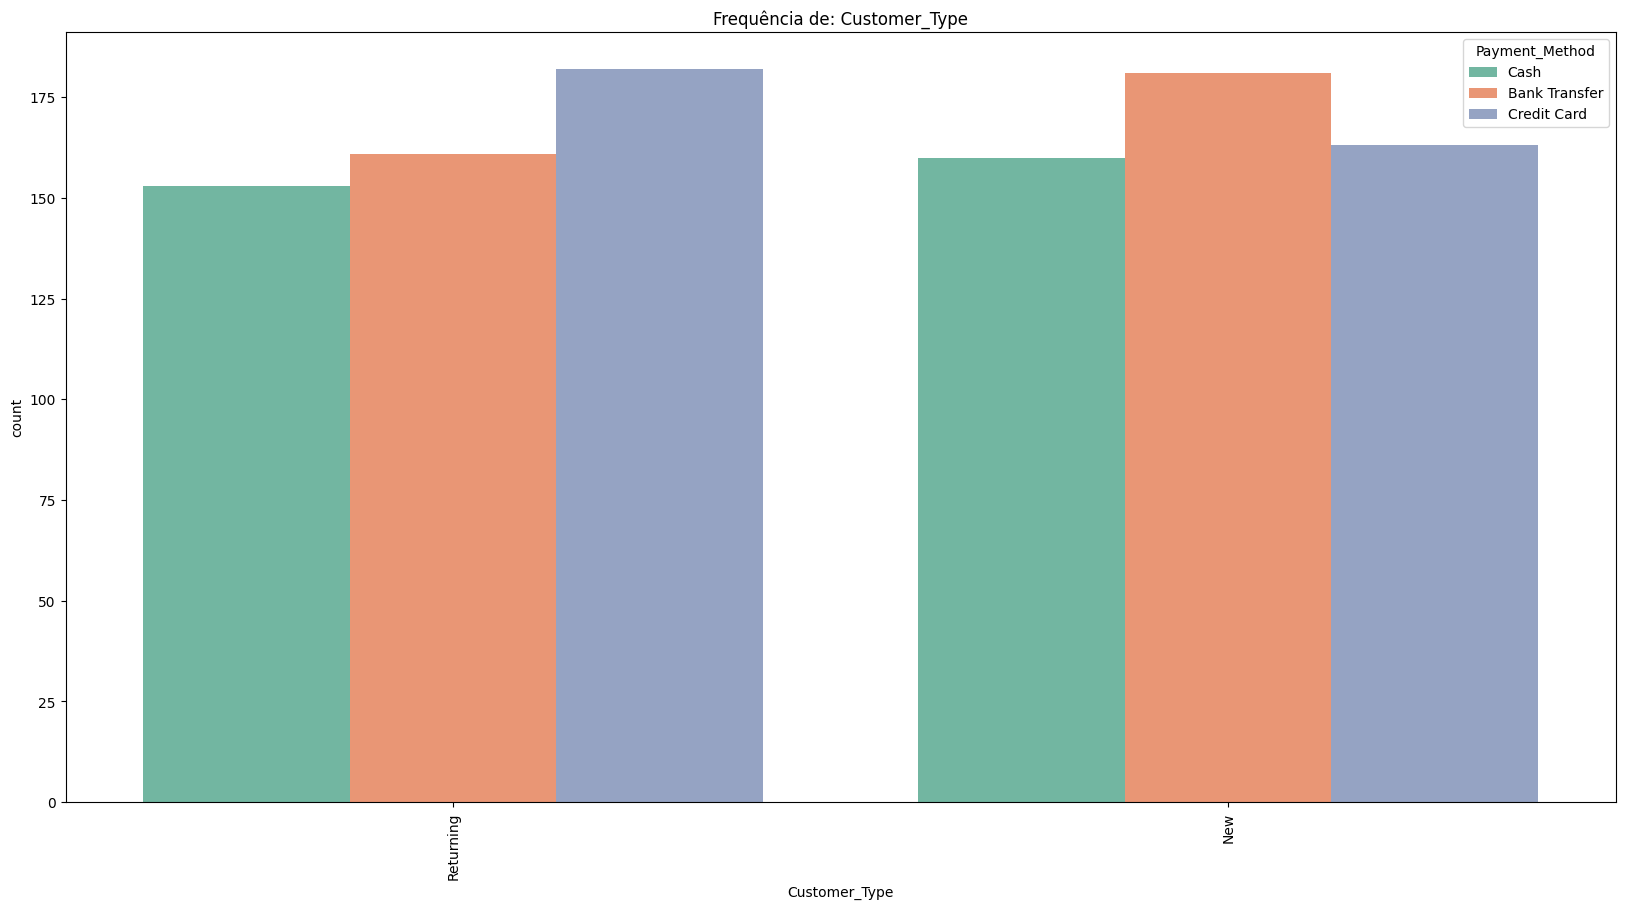

Frequência da coluna Customer_Type:
  Customer_Type Payment_Method  Frequência
0           New  Bank Transfer         181
1           New           Cash         160
2           New    Credit Card         163
3     Returning  Bank Transfer         161
4     Returning           Cash         153
5     Returning    Credit Card         182


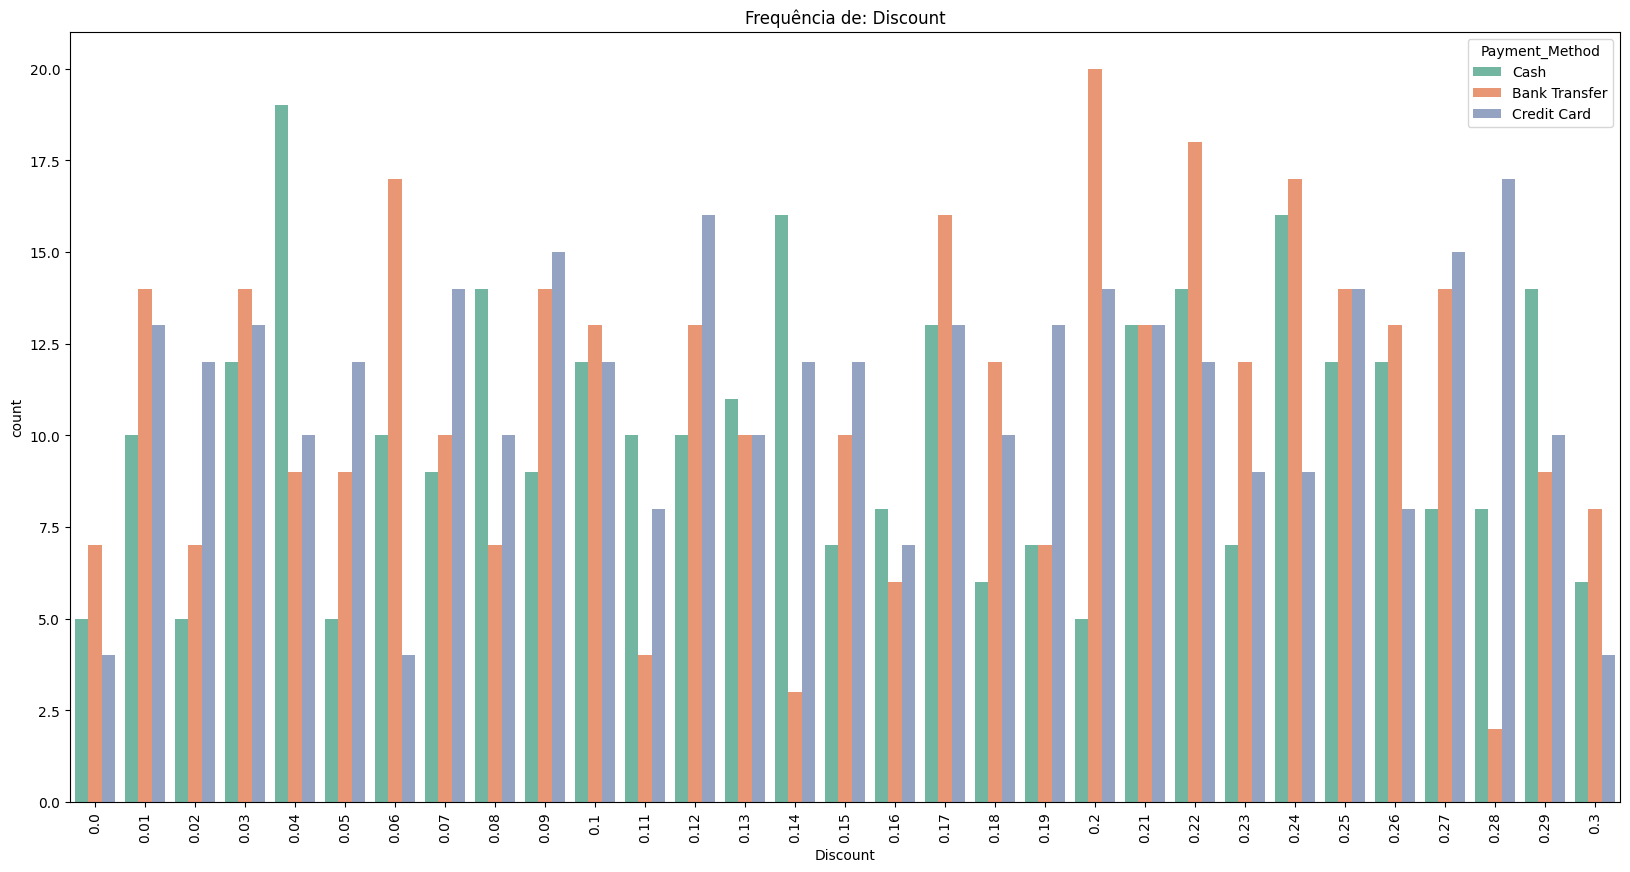

Frequência da coluna Discount:
    Discount Payment_Method  Frequência
0       0.00  Bank Transfer           7
1       0.00           Cash           5
2       0.00    Credit Card           4
3       0.01  Bank Transfer          14
4       0.01           Cash          10
..       ...            ...         ...
88      0.29           Cash          14
89      0.29    Credit Card          10
90      0.30  Bank Transfer           8
91      0.30           Cash           6
92      0.30    Credit Card           4

[93 rows x 3 columns]


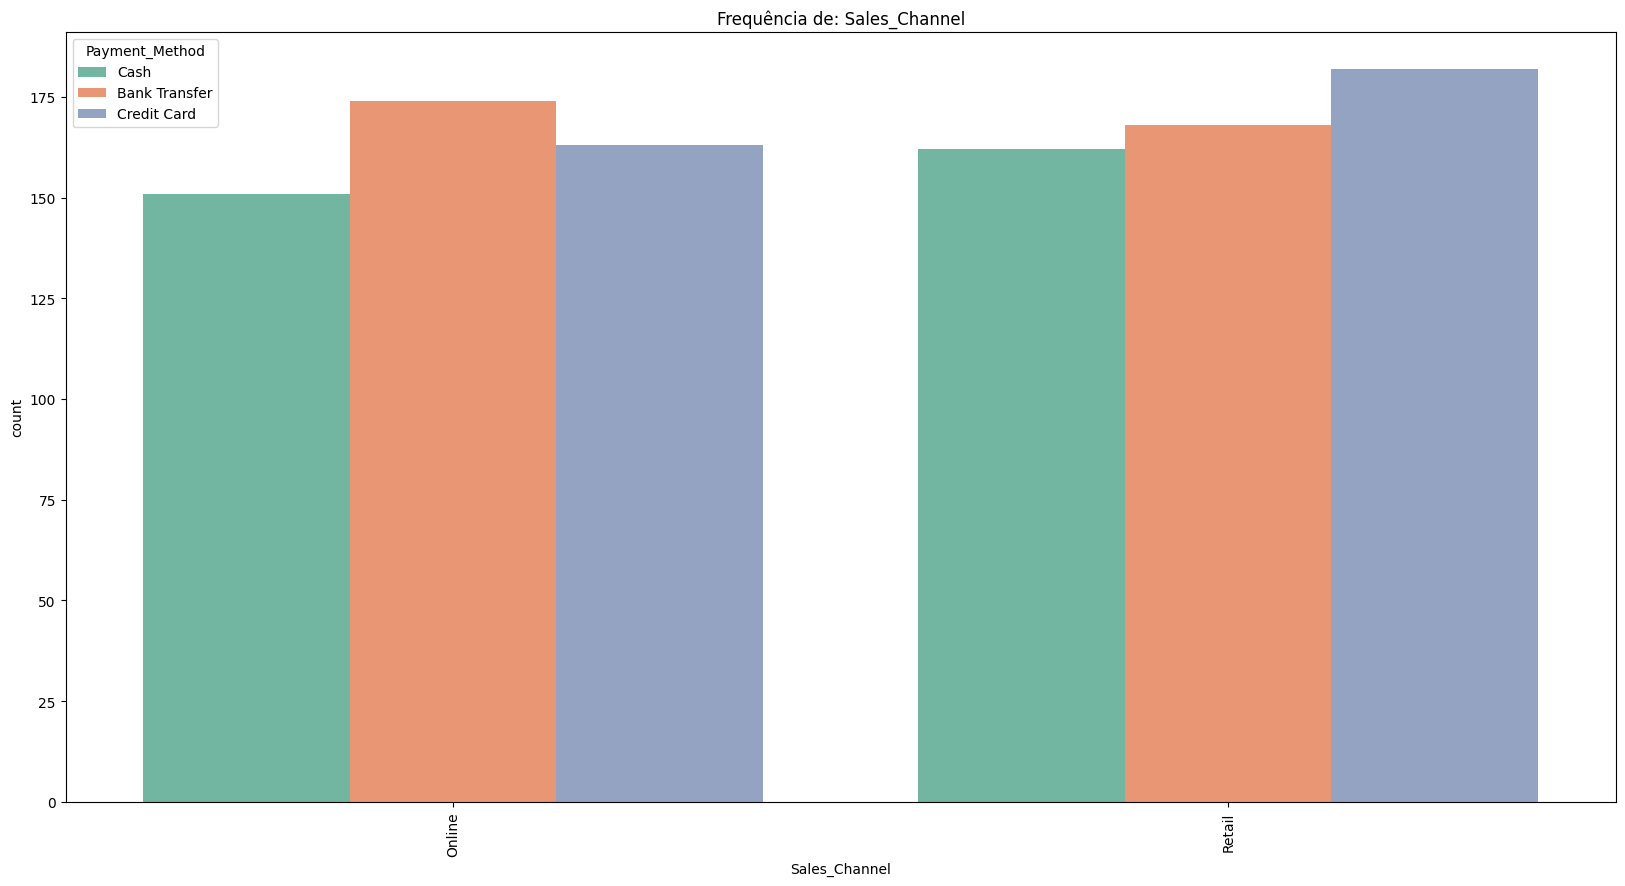

Frequência da coluna Sales_Channel:
  Sales_Channel Payment_Method  Frequência
0        Online  Bank Transfer         174
1        Online           Cash         151
2        Online    Credit Card         163
3        Retail  Bank Transfer         168
4        Retail           Cash         162
5        Retail    Credit Card         182


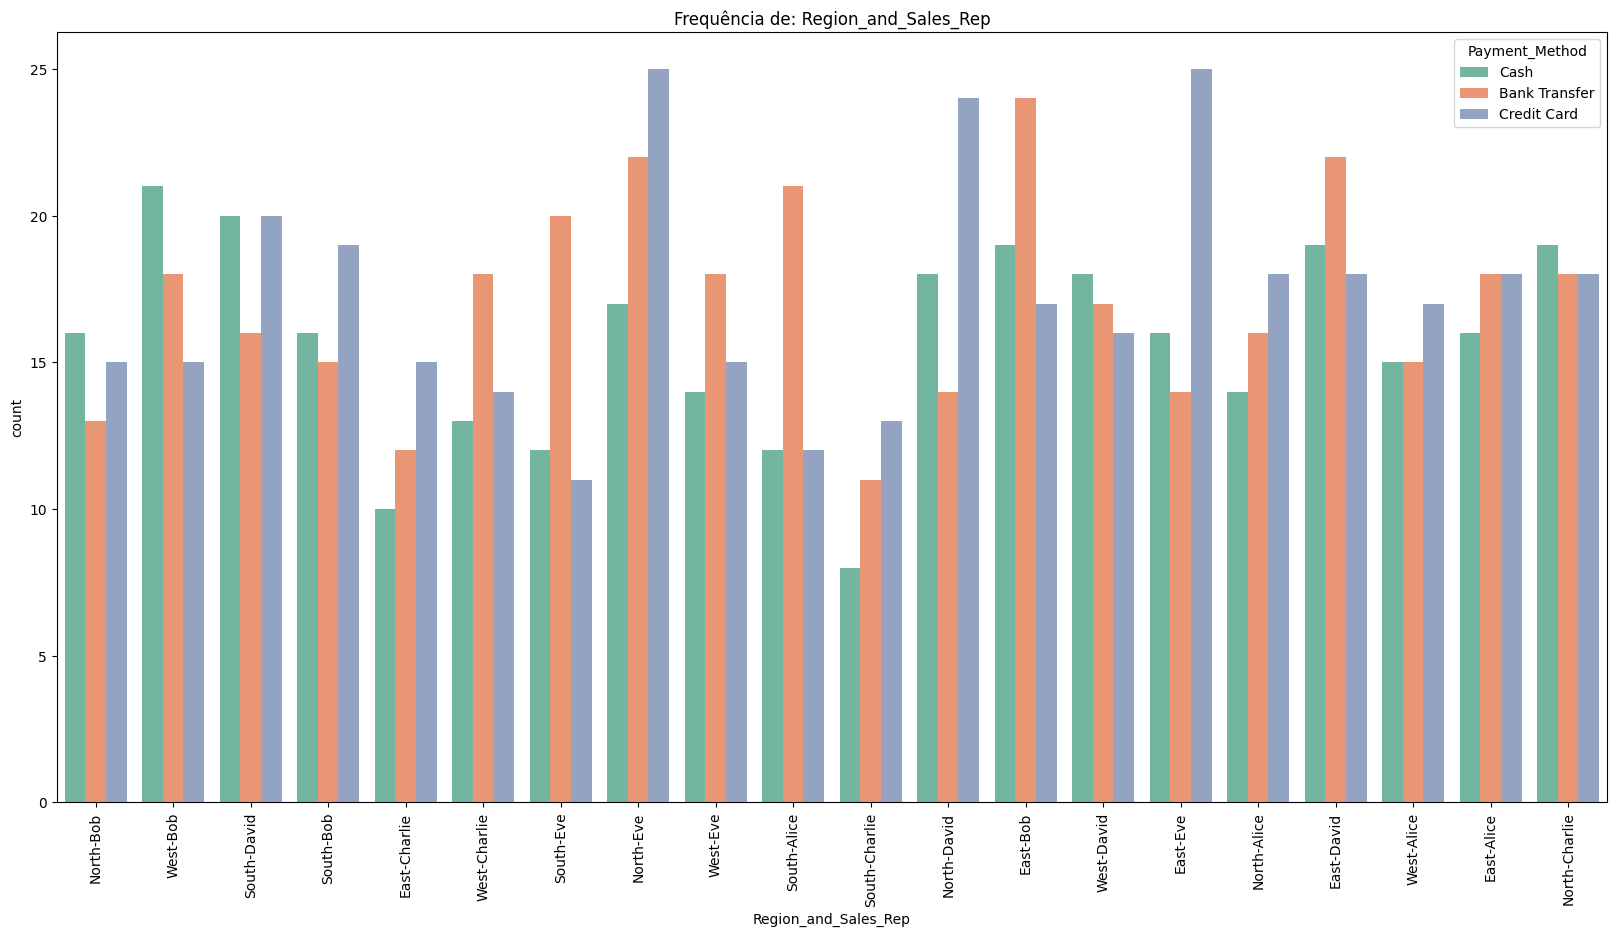

Frequência da coluna Region_and_Sales_Rep:
   Region_and_Sales_Rep Payment_Method  Frequência
0            East-Alice  Bank Transfer          18
1            East-Alice           Cash          16
2            East-Alice    Credit Card          18
3              East-Bob  Bank Transfer          24
4              East-Bob           Cash          19
5              East-Bob    Credit Card          17
6          East-Charlie  Bank Transfer          12
7          East-Charlie           Cash          10
8          East-Charlie    Credit Card          15
9            East-David  Bank Transfer          22
10           East-David           Cash          19
11           East-David    Credit Card          18
12             East-Eve  Bank Transfer          14
13             East-Eve           Cash          16
14             East-Eve    Credit Card          25
15          North-Alice  Bank Transfer          16
16          North-Alice           Cash          14
17          North-Alice    Credit Card 

In [10]:
col_pular = ['Sales_Amount', 'Unit_Cost', 'Unit_Price', 'Sale_Date', 'Payment_Method']
for col in df.columns:
    if col in col_pular:
        continue
    plt.figure(figsize=(20, 10))
    plt.title(f"Frequência de: {col}")
    plt.xlabel(f"{col}")
    plt.ylabel("Frequência")
    sns.countplot(data=df, x=col, hue='Payment_Method', palette="Set2")
    plt.xticks(rotation=90)
    plt.show()  # Exibe o gráfico
    # Conta a frequência dos valores na coluna
    qtd = df.groupby([col, 'Payment_Method']).size().reset_index(name='Frequência')
    qtd
    # Imprime as frequências
    print(f'Frequência da coluna {col}:')
    print(qtd)

# Vendedores mais frequentes

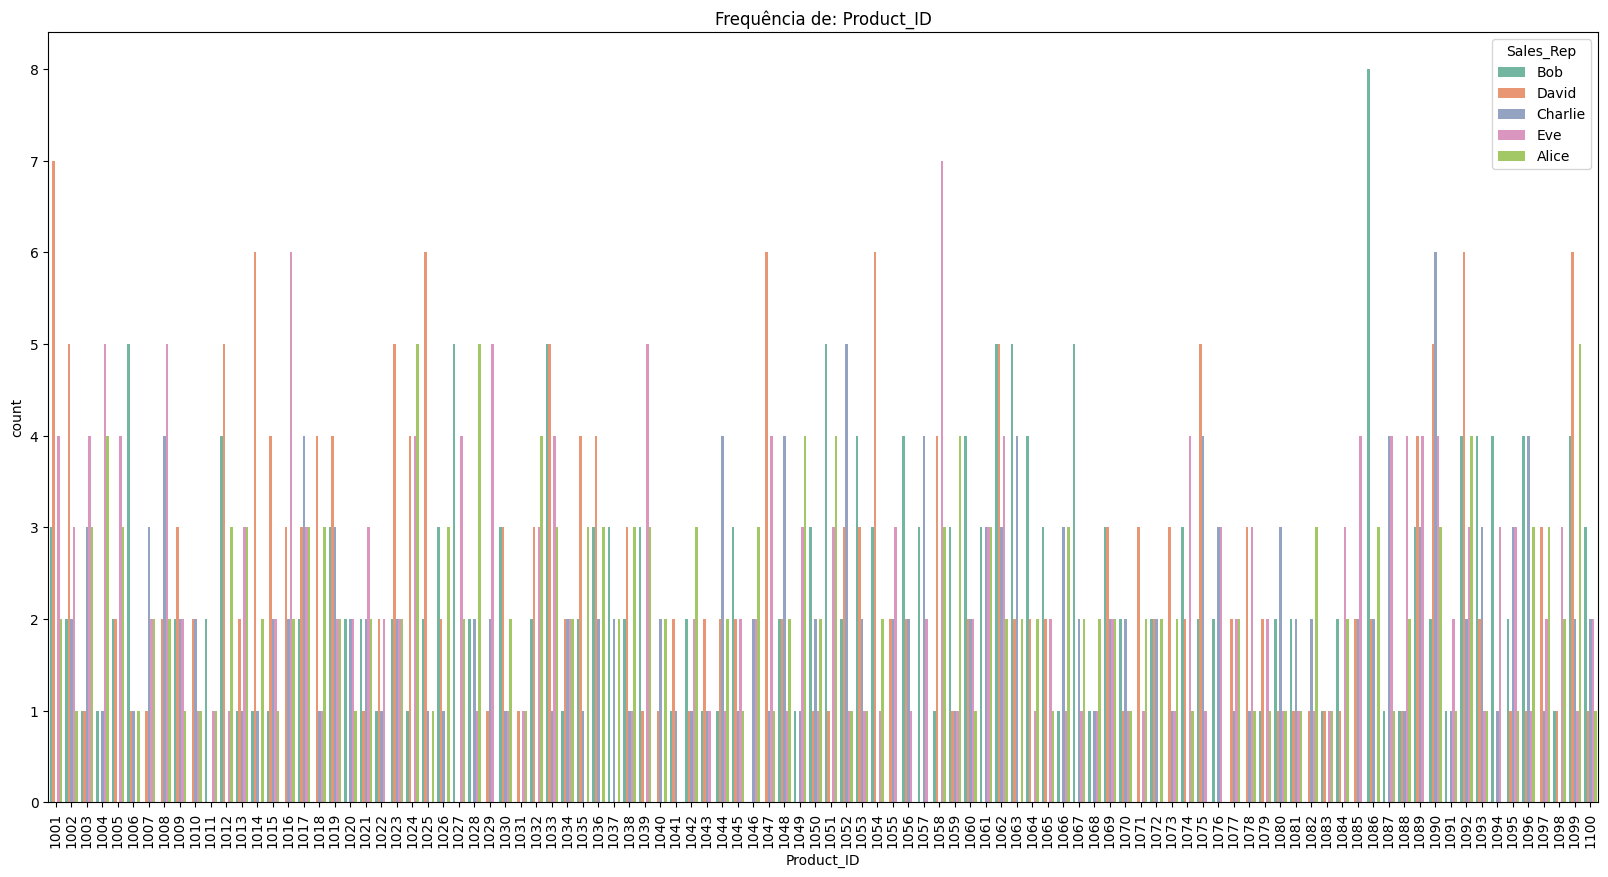

Frequência da coluna Product_ID:
     Product_ID Sales_Rep  Frequência
0          1001     Alice           2
1          1001       Bob           3
2          1001     David           7
3          1001       Eve           4
4          1002     Alice           1
..          ...       ...         ...
416        1100     Alice           1
417        1100       Bob           3
418        1100   Charlie           2
419        1100     David           1
420        1100       Eve           2

[421 rows x 3 columns]


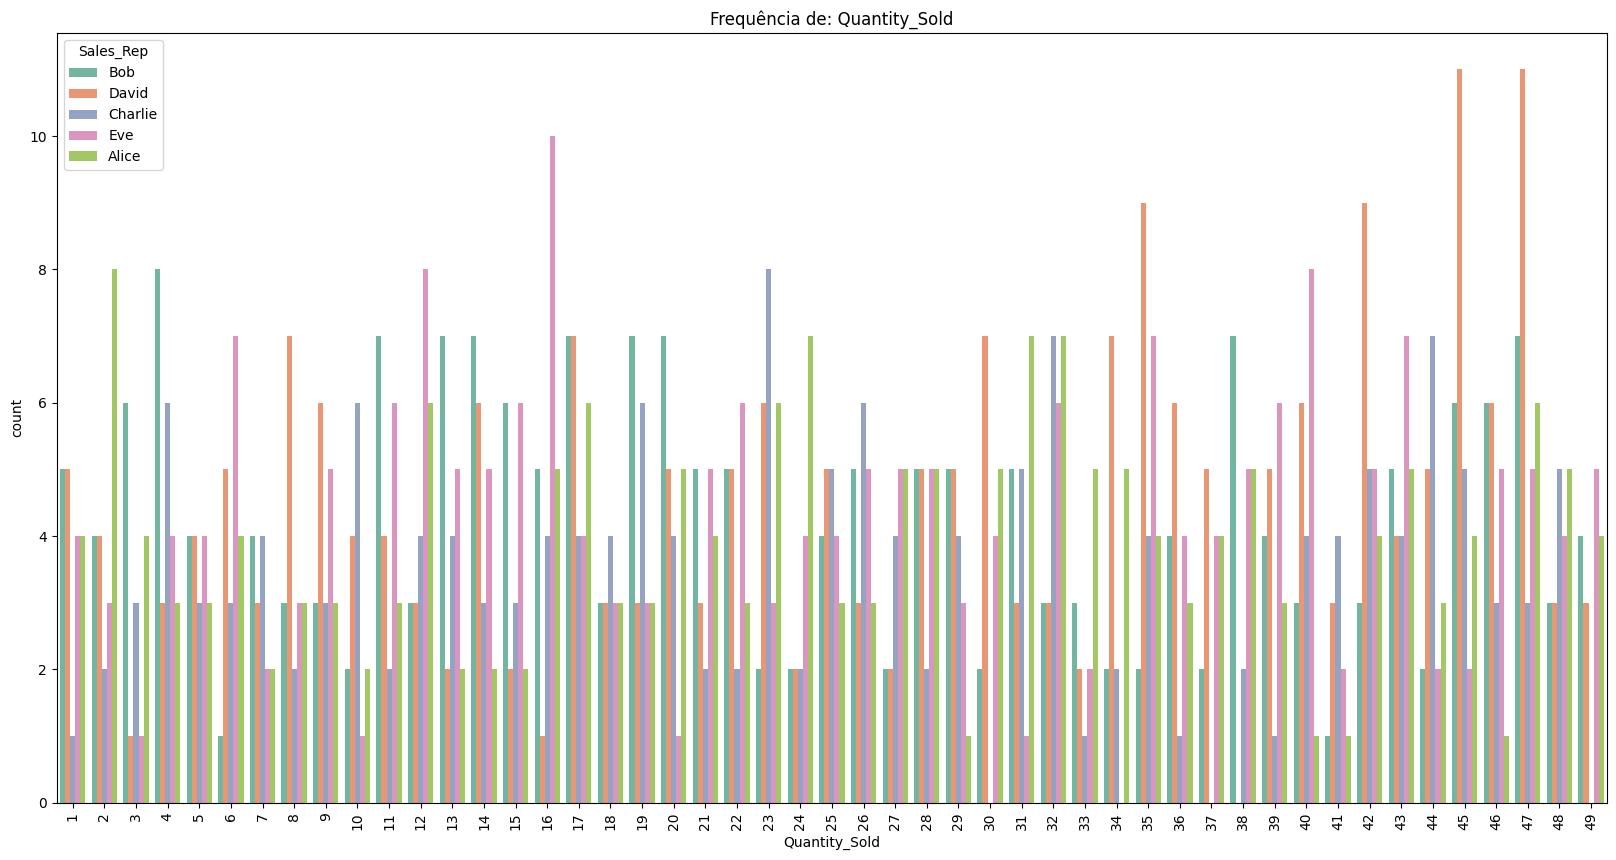

Frequência da coluna Quantity_Sold:
     Quantity_Sold Sales_Rep  Frequência
0                1     Alice           4
1                1       Bob           5
2                1   Charlie           1
3                1     David           5
4                1       Eve           4
..             ...       ...         ...
235             48       Eve           4
236             49     Alice           4
237             49       Bob           4
238             49     David           3
239             49       Eve           5

[240 rows x 3 columns]


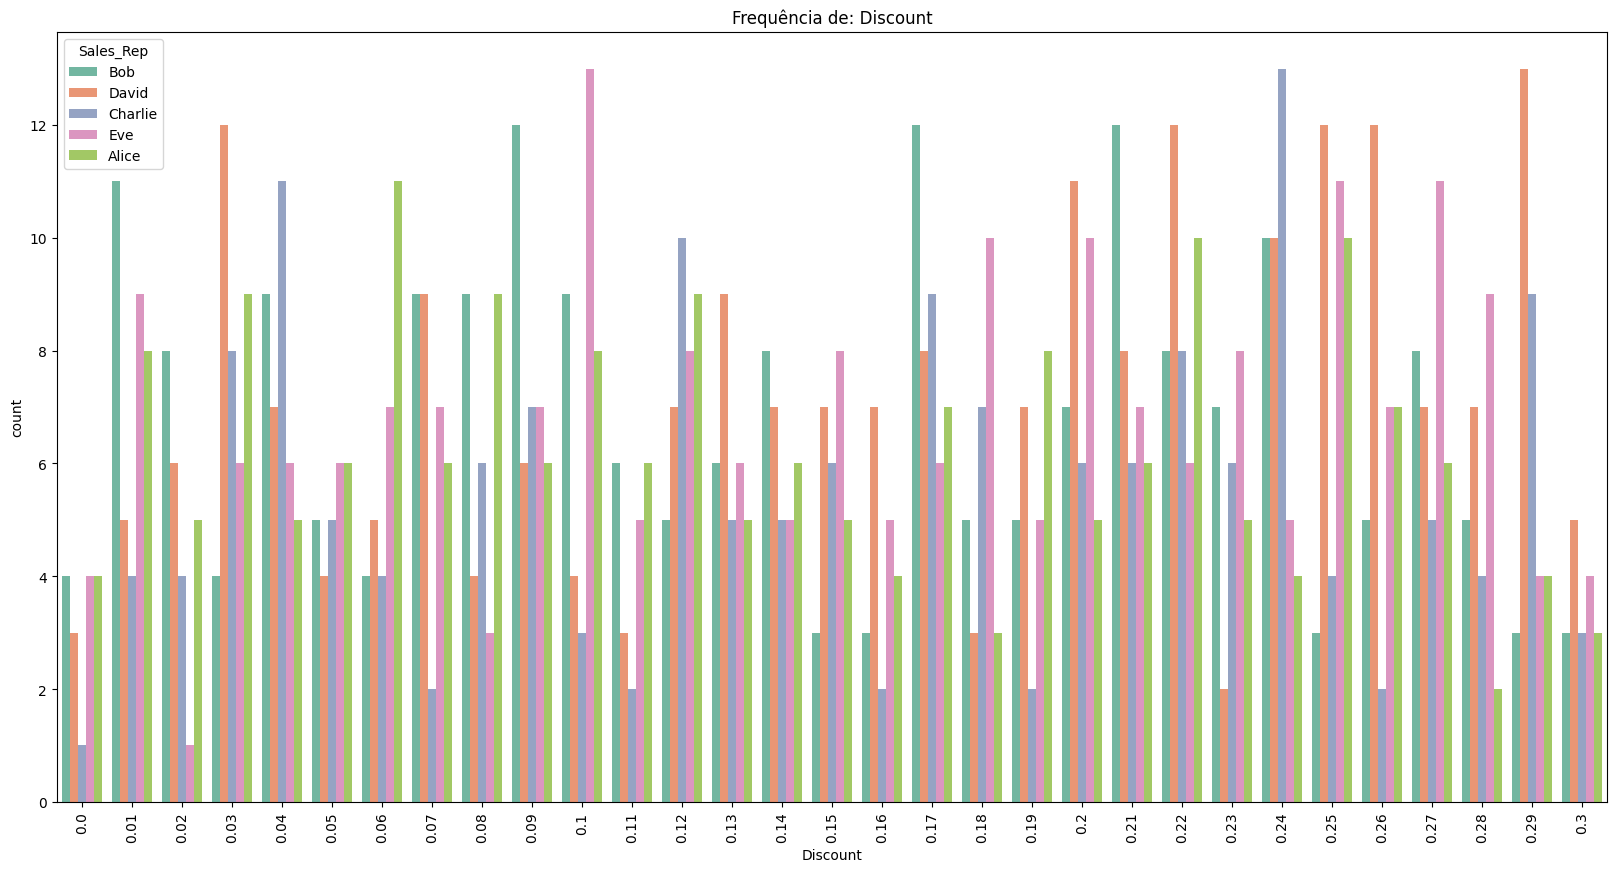

Frequência da coluna Discount:
     Discount Sales_Rep  Frequência
0         0.0     Alice           4
1         0.0       Bob           4
2         0.0   Charlie           1
3         0.0     David           3
4         0.0       Eve           4
..        ...       ...         ...
150       0.3     Alice           3
151       0.3       Bob           3
152       0.3   Charlie           3
153       0.3     David           5
154       0.3       Eve           4

[155 rows x 3 columns]


In [11]:
col_pular = ['Sales_Amount', 'Unit_Cost', 'Unit_Price', 'Sale_Date', 'Sales_Rep']
for col in col_num:
    if col in col_pular:
        continue
    plt.figure(figsize=(20, 10))
    plt.title(f"Frequência de: {col}")
    plt.xlabel(f"{col}")
    plt.ylabel("Frequência")
    sns.countplot(data=df, x=col, hue='Sales_Rep', palette="Set2")
    plt.xticks(rotation=90)
    plt.show()  # Exibe o gráfico
    # Conta a frequência dos valores na coluna
    qtd = df.groupby([col, 'Sales_Rep']).size().reset_index(name='Frequência')
    qtd
    # Imprime as frequências
    print(f'Frequência da coluna {col}:')
    print(qtd)